# **Data Study and Visualisation**

## Objectives

* Answer business requirement 1:
  * The client wants to uncover key market indicators that are most predictive of whether the stock price will go up or down the next trading day
* Evaluate and explore raw data
* Extract features for exploratory analysis
* Define the target variable for supervised learning

## Inputs

* outputs/datasets/collection/phnx_2010_2025.csv

## Outputs

* Initial visualizations of key patterns and relationships
* Generate image: plots/pearson_corr.png
* Generate image: plots/spearman_corr.png
* Generate image: plots/pps_matrix.png
* Generate image: plots/line_plot.png
* Generate image: plots/volume_plot.png

## Additional Comments

* Some feature engineering tasks were performed at this stage to support pattern discovery and visualization, even though full feature analysis will take place later. This helps guide modeling decisions and improves understanding of the dataset's structure


---

# Change working directory

* We are assuming you will store the notebooks in a subfolder, therefore when running the notebook in the editor, you will need to change the working directory

We need to change the working directory from its current folder to its parent folder
* We access the current directory with os.getcwd()

In [1]:
import os

current_dir = os.getcwd()
current_dir

'c:\\Users\\ajv10\\Documents\\vscode-projects\\PP5\\jupyter_notebooks'

We want to make the parent of the current directory the new current directory
* os.path.dirname() gets the parent directory
* os.chir() defines the new current directory

In [2]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

You set a new current directory


Confirm the new current directory

In [3]:
current_dir = os.getcwd()
current_dir

'c:\\Users\\ajv10\\Documents\\vscode-projects\\PP5'

---

# Required Imports for This Notebook

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from ydata_profiling import ProfileReport
import ppscore as pps
from feature_engine.encoding import OrdinalEncoder
from feature_engine.discretisation import ArbitraryDiscretiser

sns.set_theme(style='whitegrid')
%matplotlib inline

---

# Load Data

In [5]:
df = pd.read_csv("outputs/datasets/collection/phnx_2010_2025.csv")
print(df.shape)
df.head(3)

(3788, 8)


,date,open,high,low,close,volume,dividends,stock splits
0,2010-01-04 00:00:00+00:00,477.605706,503.724231,477.605706,497.583069,13401,0.0,0.0
1,2010-01-05 00:00:00+00:00,506.831773,509.865392,506.831773,497.583069,10729,0.0,0.0
2,2010-01-06 00:00:00+00:00,497.583069,497.583069,497.583069,497.583069,0,0.0,0.0


---

# Data Exploration

Run a comprehensive data analysis using ydata-profiling report for detailed insights

In [6]:
pandas_report = ProfileReport(df=df, minimal=True)
pandas_report.to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

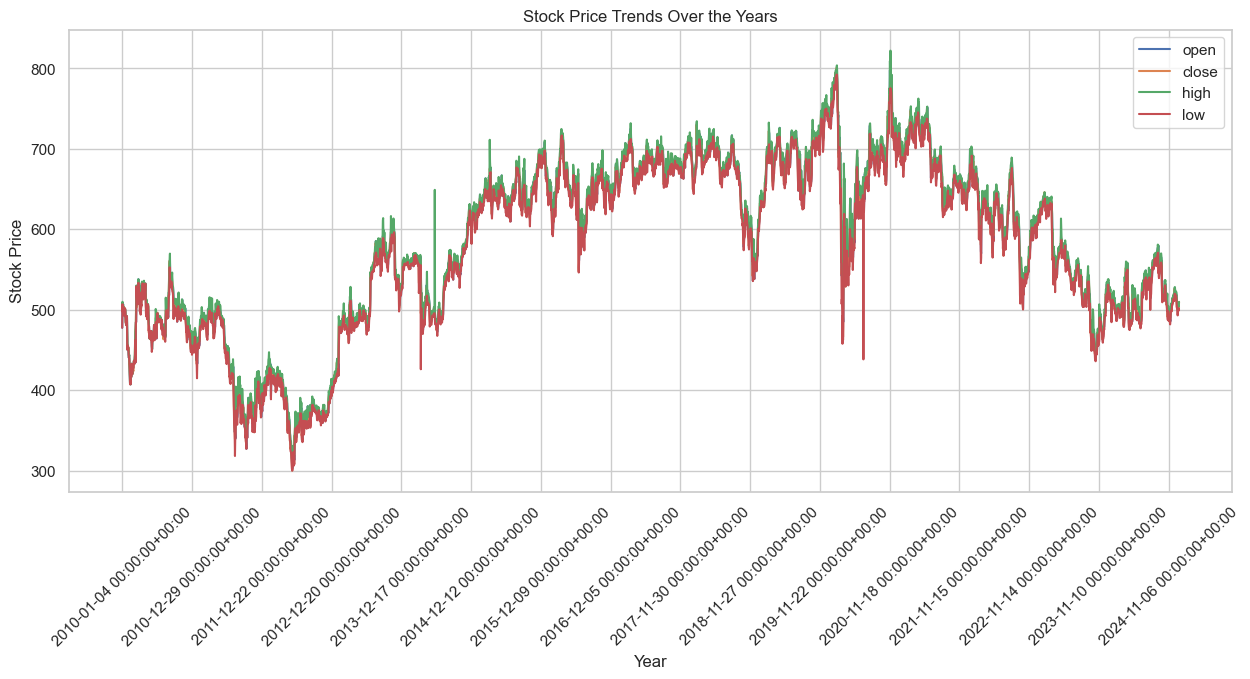

In [7]:
df.plot.line(y=['open', 'close', 'high', 'low'], figsize=(15, 6))
plt.xticks(ticks=df.index[::250], labels=df['date'][::250], rotation=45)
plt.title('Stock Price Trends Over the Years')
plt.xlabel('Year')
plt.ylabel('Stock Price')
plt.grid(True)
plt.show()

In [8]:
df.describe()

,open,high,low,close,volume,dividends,stock splits
count,3788.000000,3788.000000,3788.000000,3788.000000,3.788000e+03,3788.000000,3788.0
mean,582.033744,588.119893,575.866952,581.791430,1.334619e+06,0.114416,0.0
std,104.548640,104.737244,104.118040,104.420928,1.656785e+06,1.587428,0.0
min,302.679656,309.787594,300.088257,300.088257,0.000000e+00,0.000000,0.0
25%,499.761565,504.865513,494.300379,499.575104,3.255728e+05,0.000000,0.0
50%,603.721592,611.693679,595.700648,602.848053,9.011365e+05,0.000000,0.0
75%,670.571366,676.746803,663.955353,670.248825,1.735034e+06,0.000000,0.0
max,797.638863,821.966927,792.254833,800.630066,3.707343e+07,26.650000,0.0


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3788 entries, 0 to 3787
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          3788 non-null   object 
 1   open          3788 non-null   float64
 2   high          3788 non-null   float64
 3   low           3788 non-null   float64
 4   close         3788 non-null   float64
 5   volume        3788 non-null   int64  
 6   dividends     3788 non-null   float64
 7   stock splits  3788 non-null   float64
dtypes: float64(6), int64(1), object(1)
memory usage: 236.9+ KB


Review the average across all continuous numerical features

In [10]:
mean = df[['open','close','high','low','volume']].mean()
print(f"Open: {mean['open']:.2f}")
print(f"Close: {mean['close']:.2f}")
print(f"High: {mean['high']:.2f}")
print(f"Low: {mean['low']:.2f}")
print(f"Volume: {mean['volume']:.2f}")

Open: 582.03
Close: 581.79
High: 588.12
Low: 575.87
Volume: 1334618.54


Review the mode across all continuous numerical features, identifying a mode for this type of data can be difficult due to the high variability and lack of repetition in the values

In [11]:
mode = df[['open','close','high','low','volume']].mode()
print(mode)

         open       close       high        low  volume
0  558.637451  558.637451  486.26059  496.24463     0.0
1         NaN         NaN        NaN  521.62970     NaN


Review the median across all continuous numerical features

In [12]:
median = df[['open','close','high','low','volume']].median()
print(f"Open: {median['open']:.2f}")
print(f"Close: {median['close']:.2f}")
print(f"High: {median['high']:.2f}")
print(f"Low: {median['low']:.2f}")
print(f"Volume: {median['volume']:.2f}")

Open: 603.72
Close: 602.85
High: 611.69
Low: 595.70
Volume: 901136.50


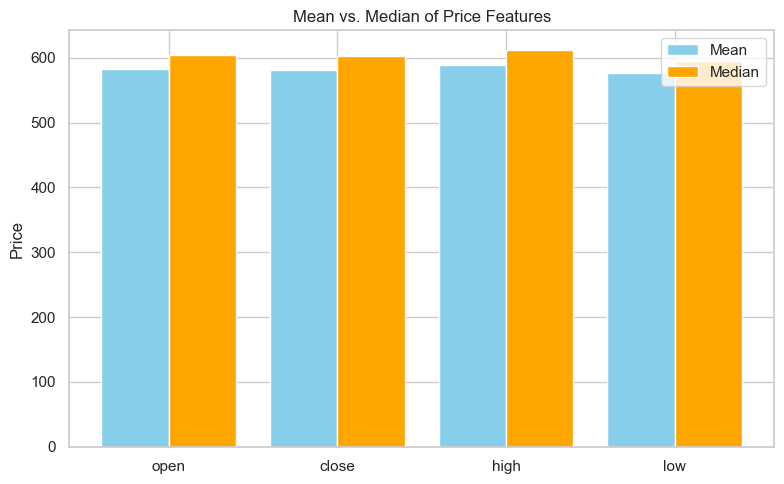

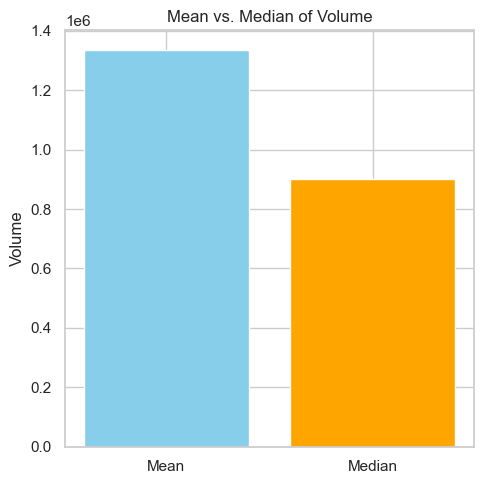

In [13]:
price_cols = ['open', 'close', 'high', 'low']
means_price = [df[col].mean() for col in price_cols]
medians_price = [df[col].median() for col in price_cols]

plt.figure(figsize=(8, 5))
x = range(len(price_cols))
plt.bar(x, means_price, width=0.4, label='Mean', color='skyblue')
plt.bar([i + 0.4 for i in x], medians_price, width=0.4, label='Median', color='orange')
plt.xticks([i + 0.2 for i in x], price_cols)
plt.ylabel('Price')
plt.title('Mean vs. Median of Price Features')
plt.legend()
plt.tight_layout()
plt.show()


volume_mean = df['volume'].mean()
volume_median = df['volume'].median()

plt.figure(figsize=(5, 5))
plt.bar(['Mean', 'Median'], [volume_mean, volume_median], color=['skyblue', 'orange'])
plt.title('Mean vs. Median of Volume')
plt.ylabel('Volume')
plt.tight_layout()
plt.show()


---

# Assessing Missing Data Levels

Drop 'dividends' and 'stock splits' since they hold no meaningfull values

In [14]:
df = df.drop(['dividends','stock splits'],axis=1)

From the YData profiling, we noticed that the volume column contains rows with a value of 0. While this may have been plausible in the early stages (e.g., around 2010), it becomes highly unlikely in later years, such as 2011 and 2017, given the high volume observed in surrounding dates. To address this, we will replace all 0 values in the volume column with NaN, so that they can be dealt with correctly using appropriate imputation techniques

In [15]:
zero_volume_rows = df[df['volume'] == 0]
zero_volume_rows.head(3)

,date,open,high,low,close,volume
2,2010-01-06 00:00:00+00:00,497.583069,497.583069,497.583069,497.583069,0
4,2010-01-08 00:00:00+00:00,503.132294,503.132294,503.132294,503.132294,0
5,2010-01-11 00:00:00+00:00,503.132294,503.132294,503.132294,503.132294,0


In [16]:
df.iloc[:10]

,date,open,high,low,close,volume
0,2010-01-04 00:00:00+00:00,477.605706,503.724231,477.605706,497.583069,13401
1,2010-01-05 00:00:00+00:00,506.831773,509.865392,506.831773,497.583069,10729
2,2010-01-06 00:00:00+00:00,497.583069,497.583069,497.583069,497.583069,0
3,2010-01-07 00:00:00+00:00,507.053752,507.053752,503.132294,503.132294,6169
4,2010-01-08 00:00:00+00:00,503.132294,503.132294,503.132294,503.132294,0
5,2010-01-11 00:00:00+00:00,503.132294,503.132294,503.132294,503.132294,0
6,2010-01-12 00:00:00+00:00,499.432739,499.432739,499.432739,499.432739,0
7,2010-01-13 00:00:00+00:00,496.399199,496.399199,496.399199,503.132294,3017
8,2010-01-14 00:00:00+00:00,501.282440,501.282440,501.282440,501.282440,0
9,2010-01-15 00:00:00+00:00,492.033668,492.033668,492.033668,499.432739,1862


In [17]:
df.iloc[333:336]

,date,open,high,low,close,volume
333,2011-04-28 00:00:00+01:00,478.851936,497.724853,478.851936,495.504547,223564
334,2011-04-29 00:00:00+01:00,495.504547,495.504547,495.504547,495.504547,0
335,2011-05-03 00:00:00+01:00,490.693760,507.716306,490.693760,499.205078,182371


In [18]:
df.iloc[1898:1901]

,date,open,high,low,close,volume
1898,2017-07-10 00:00:00+01:00,695.295257,699.324573,687.236442,690.370422,888256
1899,2017-07-11 00:00:00+01:00,690.370422,690.370422,690.370422,690.370422,0
1900,2017-07-12 00:00:00+01:00,681.416132,681.416132,672.461859,676.939026,1084099


In [19]:
def zero_count(df):
    """
    Helper function that returns the count of zero values in each column of the DataFrame
    """
    return (df == 0).sum()

zero_count(df)

date       0
open       0
high       0
low        0
close      0
volume    49
dtype: int64

In [20]:
df['volume'] = df['volume'].replace(0, np.nan)
df.head(3)

,date,open,high,low,close,volume
0,2010-01-04 00:00:00+00:00,477.605706,503.724231,477.605706,497.583069,13401.0
1,2010-01-05 00:00:00+00:00,506.831773,509.865392,506.831773,497.583069,10729.0
2,2010-01-06 00:00:00+00:00,497.583069,497.583069,497.583069,497.583069,NaN


In [21]:
zero_count(df)

date      0
open      0
high      0
low       0
close     0
volume    0
dtype: int64

In [22]:
vars_with_missing_data = df.columns[df.isna().sum() > 0].to_list()
vars_with_missing_data

['volume']

In [23]:
if vars_with_missing_data:
    profile = ProfileReport(df=df[vars_with_missing_data], minimal=True)
    profile.to_notebook_iframe()
else:
    print("There are no variables with missing data")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [24]:
def EvaluateMissingData(df):
    """
    Evaluates missing data in a DataFrame
    
    Returns a DataFrame with:
    - Count of missing values per column
    - Percentage of missing values relative to the dataset
    - Data type of each column
    Only columns with missing data are included, sorted by missing percentage
    """
    missing_data_absolute = df.isnull().sum()
    missing_data_percentage = round(missing_data_absolute/len(df)*100, 2)
    df_missing_data = (pd.DataFrame(
                            data={"RowsWithMissingData": missing_data_absolute,
                                   "PercentageOfDataset": missing_data_percentage,
                                   "DataType": df.dtypes}
                                    )
                          .sort_values(by=['PercentageOfDataset'], ascending=False)
                          .query("PercentageOfDataset > 0")
                          )

    return df_missing_data

In [25]:
EvaluateMissingData(df)

,RowsWithMissingData,PercentageOfDataset,DataType
volume,49,1.29,float64


---

# Imputation

After assessing the missing data, we noticed that the price range on rows with missing volume values often shows a repetitive pattern consistent with previous closing entries — either indicating no price movement or suggesting that a forward fill method may have been used to impute missing price data. To align with this pattern, we applied Pandas forward fill to impute the missing volume values. This approach helps maintain a more natural and realistic flow in the volume data, ensuring consistency with the existing structure

In [26]:
df['volume'] = df['volume'].ffill()

In [27]:
df.iloc[333:336]

,date,open,high,low,close,volume
333,2011-04-28 00:00:00+01:00,478.851936,497.724853,478.851936,495.504547,223564.0
334,2011-04-29 00:00:00+01:00,495.504547,495.504547,495.504547,495.504547,223564.0
335,2011-05-03 00:00:00+01:00,490.693760,507.716306,490.693760,499.205078,182371.0


In [28]:
df.iloc[1898:1901]

,date,open,high,low,close,volume
1898,2017-07-10 00:00:00+01:00,695.295257,699.324573,687.236442,690.370422,888256.0
1899,2017-07-11 00:00:00+01:00,690.370422,690.370422,690.370422,690.370422,888256.0
1900,2017-07-12 00:00:00+01:00,681.416132,681.416132,672.461859,676.939026,1084099.0


In [29]:
EvaluateMissingData(df)

,RowsWithMissingData,PercentageOfDataset,DataType


---

# Feature Extraction

## Date

To make the date feature more usable, we extract the day, month, and year into their own columns, but first we need to convert the date from object to datetime format

* Convert datetime object to a date format

In [ ]:
df['date'] = pd.to_datetime(df['date'], utc=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3788 entries, 0 to 3787
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype              
---  ------  --------------  -----              
 0   date    3788 non-null   datetime64[ns, UTC]
 1   open    3788 non-null   float64            
 2   high    3788 non-null   float64            
 3   low     3788 non-null   float64            
 4   close   3788 non-null   float64            
 5   volume  3788 non-null   float64            
dtypes: datetime64[ns, UTC](1), float64(5)
memory usage: 177.7 KB


* Extract the days of the week and the year from the 'date' column, store them in new columns, and then drop the 'date' column

In [31]:
df.insert(1, 'year', df['date'].dt.year)
df.insert(2, 'month', df['date'].dt.month_name())
df.insert(3, 'weekday', df['date'].dt.day_name())
df = df.drop(['date'],axis=1)
print(df.shape)
df.head(3)

(3788, 8)


,year,month,weekday,open,high,low,close,volume
0,2010,January,Monday,477.605706,503.724231,477.605706,497.583069,13401.0
1,2010,January,Tuesday,506.831773,509.865392,506.831773,497.583069,10729.0
2,2010,January,Wednesday,497.583069,497.583069,497.583069,497.583069,10729.0


* Use OrdinalEncoder to convert the month and weekday from object format to numerical values

In [32]:
ordinal = OrdinalEncoder(encoding_method='arbitrary', variables=df.columns[df.dtypes=='object'].to_list())
df = ordinal.fit_transform(df)
print(df.shape)
df.head()

(3788, 8)


,year,month,weekday,open,high,low,close,volume
0,2010,0,0,477.605706,503.724231,477.605706,497.583069,13401.0
1,2010,0,1,506.831773,509.865392,506.831773,497.583069,10729.0
2,2010,0,2,497.583069,497.583069,497.583069,497.583069,10729.0
3,2010,0,3,507.053752,507.053752,503.132294,503.132294,6169.0
4,2010,0,4,503.132294,503.132294,503.132294,503.132294,6169.0


In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3788 entries, 0 to 3787
Data columns (total 8 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   year     3788 non-null   int32  
 1   month    3788 non-null   int64  
 2   weekday  3788 non-null   int64  
 3   open     3788 non-null   float64
 4   high     3788 non-null   float64
 5   low      3788 non-null   float64
 6   close    3788 non-null   float64
 7   volume   3788 non-null   float64
dtypes: float64(5), int32(1), int64(2)
memory usage: 222.1 KB


## Lag Features

Create lag features by shifting previous rows to capture historical trends and support time-based pattern analysis

In [34]:
df['pre_open'] = df['open'].shift(+1)
df['pre_open_2'] = df['open'].shift(+2)

df['pre_high'] = df['high'].shift(+1)
df['pre_high_2'] = df['high'].shift(+2)

df['pre_low'] = df['low'].shift(+1)
df['pre_low_2'] = df['low'].shift(+2)

df['pre_close'] = df['close'].shift(+1)
df['pre_close_2'] = df['close'].shift(+2)

df['pre_vol'] = df['volume'].shift(+1)
df['pre_vol_2'] = df['volume'].shift(+2)

df['pre_average'] = df[['open', 'close']].mean(axis=1).shift(+1)
df['pre_average_2'] = df[['open', 'close']].mean(axis=1).shift(+2)

print(df.shape)
df

(3788, 20)


,year,month,weekday,open,high,low,close,volume,pre_open,pre_open_2,pre_high,pre_high_2,pre_low,pre_low_2,pre_close,pre_close_2,pre_vol,pre_vol_2,pre_average,pre_average_2
0,2010,0,0,477.605706,503.724231,477.605706,497.583069,13401.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2010,0,1,506.831773,509.865392,506.831773,497.583069,10729.0,477.605706,NaN,503.724231,NaN,477.605706,NaN,497.583069,NaN,13401.0,NaN,487.594388,NaN
2,2010,0,2,497.583069,497.583069,497.583069,497.583069,10729.0,506.831773,477.605706,509.865392,503.724231,506.831773,477.605706,497.583069,497.583069,10729.0,13401.0,502.207421,487.594388
3,2010,0,3,507.053752,507.053752,503.132294,503.132294,6169.0,497.583069,506.831773,497.583069,509.865392,497.583069,506.831773,497.583069,497.583069,10729.0,10729.0,497.583069,502.207421
4,2010,0,4,503.132294,503.132294,503.132294,503.132294,6169.0,507.053752,497.583069,507.053752,497.583069,503.132294,497.583069,503.132294,497.583069,6169.0,10729.0,505.093023,497.583069
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3783,2024,11,0,498.162306,502.260357,496.762980,501.260834,1071229.0,499.761560,501.260839,502.260368,501.760601,492.964815,497.162789,500.261322,500.761078,3415182.0,1667456.0,500.011441,501.010959
3784,2024,11,1,502.260351,505.258920,501.760590,501.760590,436491.0,498.162306,499.761560,502.260357,502.260368,496.762980,492.964815,501.260834,500.261322,1071229.0,3415182.0,499.711570,500.011441
3785,2024,11,4,500.261324,503.759655,500.261324,502.760132,881757.0,502.260351,498.162306,505.258920,502.260357,501.760590,496.762980,501.760590,501.260834,436491.0,1071229.0,502.010470,499.711570
3786,2024,11,0,501.760601,504.759170,498.961948,500.761078,608408.0,500.261324,502.260351,503.759655,505.258920,500.261324,501.760590,502.760132,501.760590,881757.0,436491.0,501.510728,502.010470


---

# Target Variable Definition for Classification and Regression

Create a regression target by calculating tomorrow’s average price (mean of open and close). This target was chosen arbitrarily

In [35]:
df['average'] = df[['open', 'close']].mean(axis=1)

In [36]:
highest = df['average'].max()
lowest = df['average'].min()

print(f"Highest average price: {highest}")
print(f"Lowest average price: {lowest}")

Highest average price: 798.1872845545624
Lowest average price: 302.6796799197552


In [37]:
df['tomorrows_average'] = df[['open', 'close']].mean(axis=1).shift(-1)
print(df.shape)
df

(3788, 22)


,year,month,weekday,open,high,low,close,volume,pre_open,pre_open_2,...,pre_low,pre_low_2,pre_close,pre_close_2,pre_vol,pre_vol_2,pre_average,pre_average_2,average,tomorrows_average
0,2010,0,0,477.605706,503.724231,477.605706,497.583069,13401.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,487.594388,502.207421
1,2010,0,1,506.831773,509.865392,506.831773,497.583069,10729.0,477.605706,NaN,...,477.605706,NaN,497.583069,NaN,13401.0,NaN,487.594388,NaN,502.207421,497.583069
2,2010,0,2,497.583069,497.583069,497.583069,497.583069,10729.0,506.831773,477.605706,...,506.831773,477.605706,497.583069,497.583069,10729.0,13401.0,502.207421,487.594388,497.583069,505.093023
3,2010,0,3,507.053752,507.053752,503.132294,503.132294,6169.0,497.583069,506.831773,...,497.583069,506.831773,497.583069,497.583069,10729.0,10729.0,497.583069,502.207421,505.093023,503.132294
4,2010,0,4,503.132294,503.132294,503.132294,503.132294,6169.0,507.053752,497.583069,...,503.132294,497.583069,503.132294,497.583069,6169.0,10729.0,505.093023,497.583069,503.132294,503.132294
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3783,2024,11,0,498.162306,502.260357,496.762980,501.260834,1071229.0,499.761560,501.260839,...,492.964815,497.162789,500.261322,500.761078,3415182.0,1667456.0,500.011441,501.010959,499.711570,502.010470
3784,2024,11,1,502.260351,505.258920,501.760590,501.760590,436491.0,498.162306,499.761560,...,496.762980,492.964815,501.260834,500.261322,1071229.0,3415182.0,499.711570,500.011441,502.010470,501.510728
3785,2024,11,4,500.261324,503.759655,500.261324,502.760132,881757.0,502.260351,498.162306,...,501.760590,496.762980,501.760590,501.260834,436491.0,1071229.0,502.010470,499.711570,501.510728,501.260839
3786,2024,11,0,501.760601,504.759170,498.961948,500.761078,608408.0,500.261324,502.260351,...,500.261324,501.760590,502.760132,501.760590,881757.0,436491.0,501.510728,502.010470,501.260839,506.008563


Classification target: Created by comparing tomorrow’s average price (mean of open and close) to today’s, labeling as 1 if higher and 0 if lower, chosen arbitrarily to explore directional prediction

In [38]:
df['target'] = (df['tomorrows_average'] > df['average']).astype(int)
print(df.shape)
df

(3788, 23)


,year,month,weekday,open,high,low,close,volume,pre_open,pre_open_2,...,pre_low_2,pre_close,pre_close_2,pre_vol,pre_vol_2,pre_average,pre_average_2,average,tomorrows_average,target
0,2010,0,0,477.605706,503.724231,477.605706,497.583069,13401.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,487.594388,502.207421,1
1,2010,0,1,506.831773,509.865392,506.831773,497.583069,10729.0,477.605706,NaN,...,NaN,497.583069,NaN,13401.0,NaN,487.594388,NaN,502.207421,497.583069,0
2,2010,0,2,497.583069,497.583069,497.583069,497.583069,10729.0,506.831773,477.605706,...,477.605706,497.583069,497.583069,10729.0,13401.0,502.207421,487.594388,497.583069,505.093023,1
3,2010,0,3,507.053752,507.053752,503.132294,503.132294,6169.0,497.583069,506.831773,...,506.831773,497.583069,497.583069,10729.0,10729.0,497.583069,502.207421,505.093023,503.132294,0
4,2010,0,4,503.132294,503.132294,503.132294,503.132294,6169.0,507.053752,497.583069,...,497.583069,503.132294,497.583069,6169.0,10729.0,505.093023,497.583069,503.132294,503.132294,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3783,2024,11,0,498.162306,502.260357,496.762980,501.260834,1071229.0,499.761560,501.260839,...,497.162789,500.261322,500.761078,3415182.0,1667456.0,500.011441,501.010959,499.711570,502.010470,1
3784,2024,11,1,502.260351,505.258920,501.760590,501.760590,436491.0,498.162306,499.761560,...,492.964815,501.260834,500.261322,1071229.0,3415182.0,499.711570,500.011441,502.010470,501.510728,0
3785,2024,11,4,500.261324,503.759655,500.261324,502.760132,881757.0,502.260351,498.162306,...,496.762980,501.760590,501.260834,436491.0,1071229.0,502.010470,499.711570,501.510728,501.260839,0
3786,2024,11,0,501.760601,504.759170,498.961948,500.761078,608408.0,500.261324,502.260351,...,501.760590,502.760132,501.760590,881757.0,436491.0,501.510728,502.010470,501.260839,506.008563,1


In [39]:
EvaluateMissingData(df)

,RowsWithMissingData,PercentageOfDataset,DataType
pre_high_2,2,0.05,float64
pre_average_2,2,0.05,float64
pre_vol_2,2,0.05,float64
pre_open_2,2,0.05,float64
pre_close_2,2,0.05,float64
pre_low_2,2,0.05,float64
pre_close,1,0.03,float64
tomorrows_average,1,0.03,float64
pre_average,1,0.03,float64
pre_vol,1,0.03,float64


Since the data has been shifted, it has created some rows with NaN values. An imputation method could be used again to replace the remaining missing data. However, since the amount of missing data is very small, we will simply drop those rows instead

In [40]:
df = df.dropna()
print(df.shape)
df

(3785, 23)


,year,month,weekday,open,high,low,close,volume,pre_open,pre_open_2,...,pre_low_2,pre_close,pre_close_2,pre_vol,pre_vol_2,pre_average,pre_average_2,average,tomorrows_average,target
2,2010,0,2,497.583069,497.583069,497.583069,497.583069,10729.0,506.831773,477.605706,...,477.605706,497.583069,497.583069,10729.0,13401.0,502.207421,487.594388,497.583069,505.093023,1
3,2010,0,3,507.053752,507.053752,503.132294,503.132294,6169.0,497.583069,506.831773,...,506.831773,497.583069,497.583069,10729.0,10729.0,497.583069,502.207421,505.093023,503.132294,0
4,2010,0,4,503.132294,503.132294,503.132294,503.132294,6169.0,507.053752,497.583069,...,497.583069,503.132294,497.583069,6169.0,10729.0,505.093023,497.583069,503.132294,503.132294,0
5,2010,0,0,503.132294,503.132294,503.132294,503.132294,6169.0,503.132294,507.053752,...,503.132294,503.132294,503.132294,6169.0,6169.0,503.132294,505.093023,503.132294,499.432739,0
6,2010,0,1,499.432739,499.432739,499.432739,499.432739,6169.0,503.132294,503.132294,...,503.132294,503.132294,503.132294,6169.0,6169.0,503.132294,503.132294,499.432739,499.765746,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3782,2024,11,4,499.761560,502.260368,492.964815,500.261322,3415182.0,501.260839,504.759155,...,502.760109,500.761078,504.759155,1667456.0,1369942.0,501.010959,504.759155,500.011441,499.711570,0
3783,2024,11,0,498.162306,502.260357,496.762980,501.260834,1071229.0,499.761560,501.260839,...,497.162789,500.261322,500.761078,3415182.0,1667456.0,500.011441,501.010959,499.711570,502.010470,1
3784,2024,11,1,502.260351,505.258920,501.760590,501.760590,436491.0,498.162306,499.761560,...,492.964815,501.260834,500.261322,1071229.0,3415182.0,499.711570,500.011441,502.010470,501.510728,0
3785,2024,11,4,500.261324,503.759655,500.261324,502.760132,881757.0,502.260351,498.162306,...,496.762980,501.760590,501.260834,436491.0,1071229.0,502.010470,499.711570,501.510728,501.260839,0


In [41]:
EvaluateMissingData(df)

,RowsWithMissingData,PercentageOfDataset,DataType


---

# Target Imbalance

Target imbalance is typically a classification issue, but for regression, we will also check tomorrow's average to assess the distribution of the target variable

* Classification

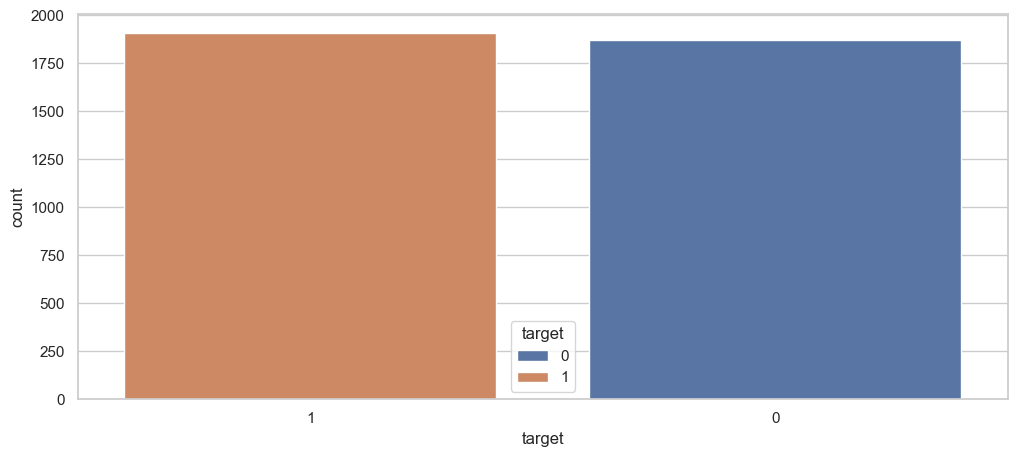

In [42]:
plt.figure(figsize=(12, 5))
sns.countplot(data=df, x='target', hue='target', order=df['target'].value_counts().index)
plt.show()

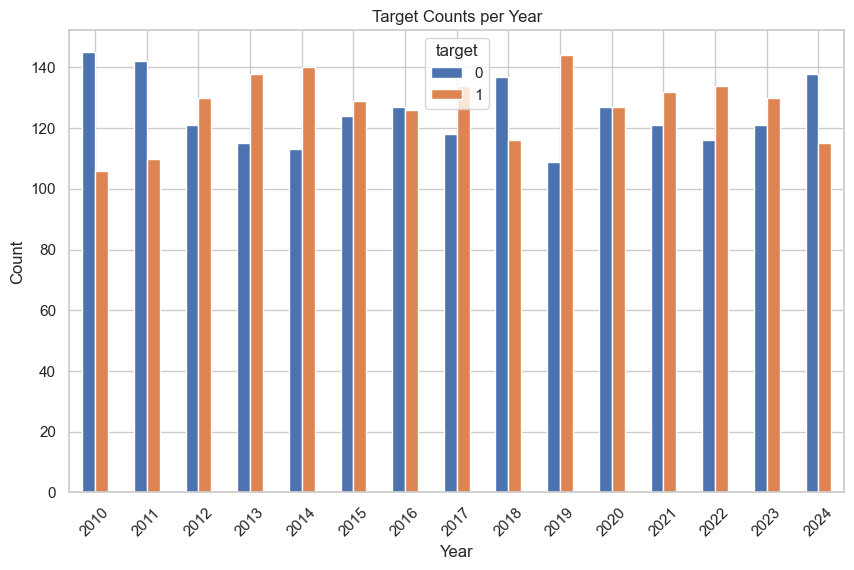

In [43]:
count = df.groupby(['year', 'target']).size().unstack(fill_value=0)
count.plot(kind='bar', figsize=(10, 6))
plt.title('Target Counts per Year')
plt.xlabel('Year')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

* Regression

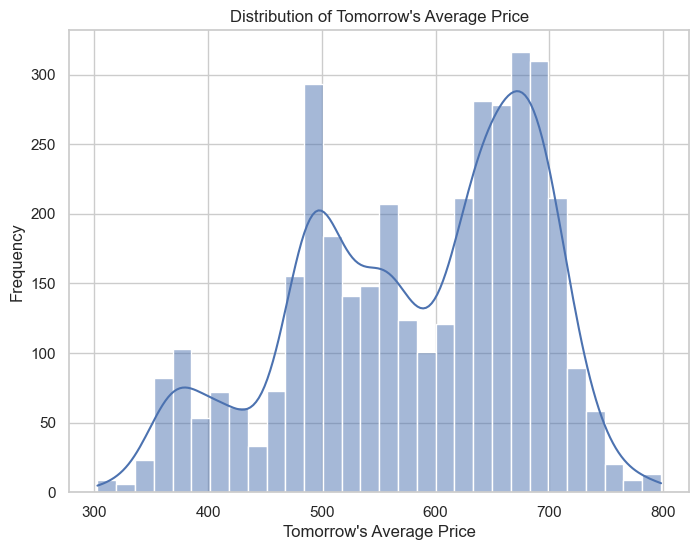

In [44]:
plt.figure(figsize=(8, 6))
sns.histplot(df['tomorrows_average'], bins=30, kde=True)
plt.title('Distribution of Tomorrow\'s Average Price')
plt.xlabel('Tomorrow\'s Average Price')
plt.ylabel('Frequency')
plt.show()

Due to the targets being relatively balanced, techniques to address class imbalance were not necessary. However, had there been an imbalance, SMOTE (Synthetic Minority Over-sampling Technique) can be used, as it is well-suited for smaller datasets

---

# Correlation and PPS Analysis

In [45]:
def heatmap_corr(df, threshold, figsize=(20, 12), font_annot=8):
    """
    Plots a heatmap of the correlation matrix, masking values below a given threshold 
    and the upper triangle for clarity

    Parameters:
    df (DataFrame): Correlation matrix to visualize
    threshold (float): Minimum absolute correlation value to display
    figsize (tuple): Size of the figure (width, height)
    font_annot (int): Font size for annotation labels

    Returns:
    None: Displays the heatmap plot
    """
    if len(df.columns) > 1:
        mask = np.zeros_like(df, dtype=bool)
        mask[np.triu_indices_from(mask)] = True
        mask[abs(df) < threshold] = True

        fig, axes = plt.subplots(figsize=figsize)
        sns.heatmap(df, annot=True, xticklabels=True, yticklabels=True,
                    mask=mask, cmap='viridis', annot_kws={"size": font_annot},
                    fmt='.1f', ax=axes,
                    linewidth=0.5, linecolor='grey')
        axes.set_yticklabels(df.columns, rotation=0)
        plt.ylim(len(df.columns), 0)
        plt.show()


def heatmap_pps(df, threshold, figsize=(20, 12), font_annot=8):
    """
    Plot a heatmap of predictive power scores (PPS) for feature relationships, 
    masking values below a specified threshold

    Parameters:
    df (DataFrame): DataFrame of predictive power scores (PPS) to visualize
    threshold (float): Minimum PPS value to display (values below are masked)
    figsize (tuple): Figure size as (width, height)
    font_annot (int): Font size for annotations in the heatmap

    Returns:
    None: Displays the heatmap plot
    """
    if len(df.columns) > 1:
        mask = np.zeros_like(df, dtype=bool)
        mask[abs(df) < threshold] = True
        fig, ax = plt.subplots(figsize=figsize)
        ax = sns.heatmap(df, annot=True, xticklabels=True, yticklabels=True,
                         mask=mask, cmap='rocket_r', annot_kws={"size": font_annot},
                         fmt='.1f',
                         linewidth=0.05, linecolor='grey')
        plt.ylim(len(df.columns), 0)
        plt.show()


def CalculateCorrAndPPS(df):
    """
    Calculate Pearson and Spearman correlation matrices, 
    and generate a Predictive Power Score (PPS) matrix

    Parameters:
        df (DataFrame): Input data for correlation and PPS calculation

    Returns:
        tuple: Pearson correlation matrix (DataFrame), 
            Spearman correlation matrix (DataFrame), 
            PPS matrix (DataFrame)
    """
    df_corr_spearman = df.corr(method="spearman", numeric_only=True)
    df_corr_pearson = df.corr(method="pearson", numeric_only=True)

    pps_matrix_raw = pps.matrix(df)
    pps_matrix = pps_matrix_raw.filter(['x', 'y', 'ppscore']).pivot(columns='x', index='y', values='ppscore')

    pps_score_stats = pps_matrix_raw.query("ppscore < 1").filter(['ppscore']).describe().T
    print("PPS threshold - check PPS score IQR to decide threshold for heatmap \n")
    print(pps_score_stats.round(3))

    return df_corr_pearson, df_corr_spearman, pps_matrix


def DisplayCorrAndPPS(df_corr_pearson, df_corr_spearman, pps_matrix, CorrThreshold, PPS_Threshold,
                      figsize=(20, 12), font_annot=8):
    """
    Display heatmaps for correlation and predictive power scores

    Parameters:
        df_corr_pearson (DataFrame): Pearson correlation matrix showing linear relationships
        df_corr_spearman (DataFrame): Spearman correlation matrix showing monotonic relationships
        pps_matrix (DataFrame): Power Predictive Score matrix showing predictive strength between variables
        CorrThreshold (float): Threshold to filter correlation values displayed in heatmaps
        PPS_Threshold (float): Threshold to filter PPS values displayed in heatmap
        figsize (tuple, optional): Size of the heatmap figures (width, height). Default is (20, 12)
        font_annot (int, optional): Font size for annotation labels in heatmaps. Default is 8

    Displays:
        Prints explanatory messages and visualizes heatmaps for Spearman correlation, Pearson correlation, and PPS
    """
    print("\n")
    print("* Analyse how the target variable for your ML models are correlated with other variables (features and target)")
    print("* Analyse multi-colinearity, that is, how the features are correlated among themselves")

    print("\n")
    print("*** Heatmap: Spearman Correlation ***")
    print("It evaluates monotonic relationship \n")
    heatmap_corr(df=df_corr_spearman, threshold=CorrThreshold, figsize=figsize, font_annot=font_annot)

    print("\n")
    print("*** Heatmap: Pearson Correlation ***")
    print("It evaluates the linear relationship between two continuous variables \n")
    heatmap_corr(df=df_corr_pearson, threshold=CorrThreshold, figsize=figsize, font_annot=font_annot)

    print("\n")
    print("*** Heatmap: Power Predictive Score (PPS) ***")
    print(f"PPS detects linear or non-linear relationships between two columns.\n"
          f"The score ranges from 0 (no predictive power) to 1 (perfect predictive power) \n")
    heatmap_pps(df=pps_matrix, threshold=PPS_Threshold, figsize=figsize, font_annot=font_annot)

In [46]:
df_corr_pearson, df_corr_spearman, pps_matrix = CalculateCorrAndPPS(df)

PPS threshold - check PPS score IQR to decide threshold for heatmap 

         count  mean    std  min  25%    50%    75%    max
ppscore  506.0  0.47  0.425  0.0  0.0  0.652  0.899  0.955


The PPS scores show that about 50% of feature pairs have a score above 0.65, and the top 25% have a score above 0.9, indicating moderate to strong predictive relationships among these features



* Analyse how the target variable for your ML models are correlated with other variables (features and target)
* Analyse multi-colinearity, that is, how the features are correlated among themselves


*** Heatmap: Spearman Correlation ***
It evaluates monotonic relationship 



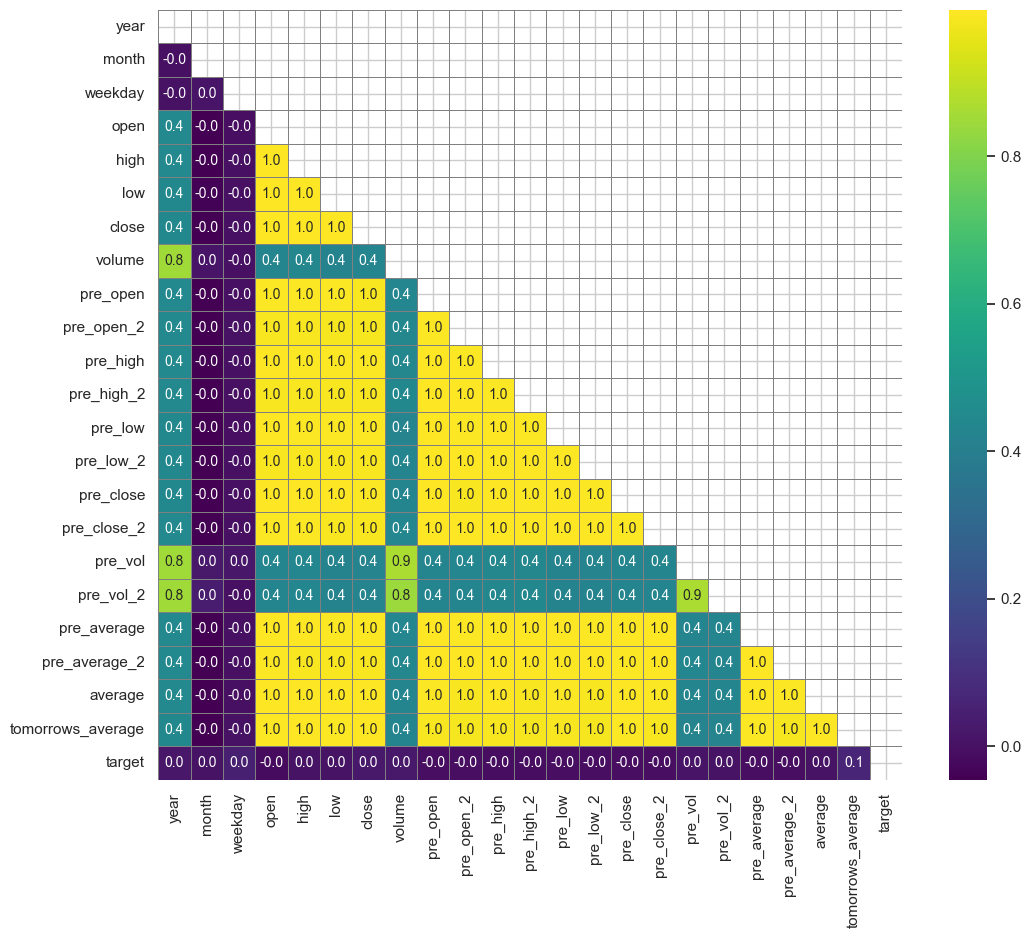



*** Heatmap: Pearson Correlation ***
It evaluates the linear relationship between two continuous variables 



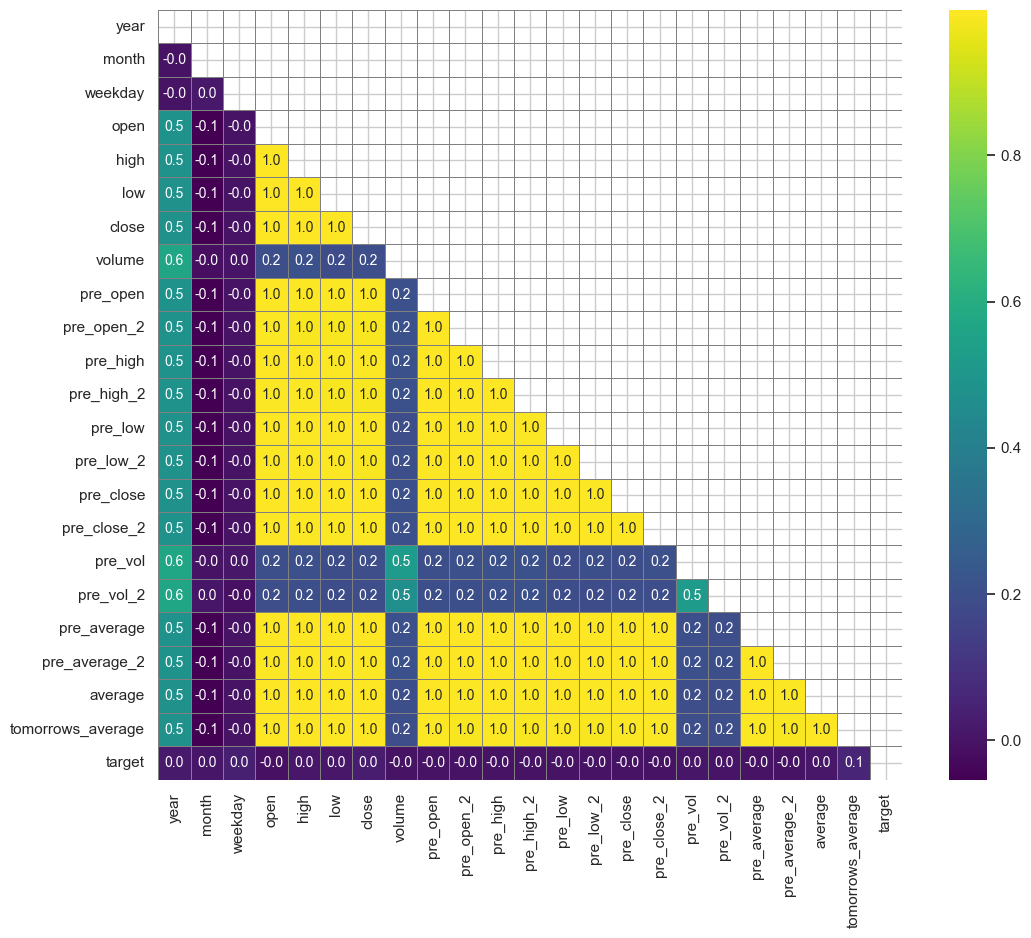



*** Heatmap: Power Predictive Score (PPS) ***
PPS detects linear or non-linear relationships between two columns.
The score ranges from 0 (no predictive power) to 1 (perfect predictive power) 



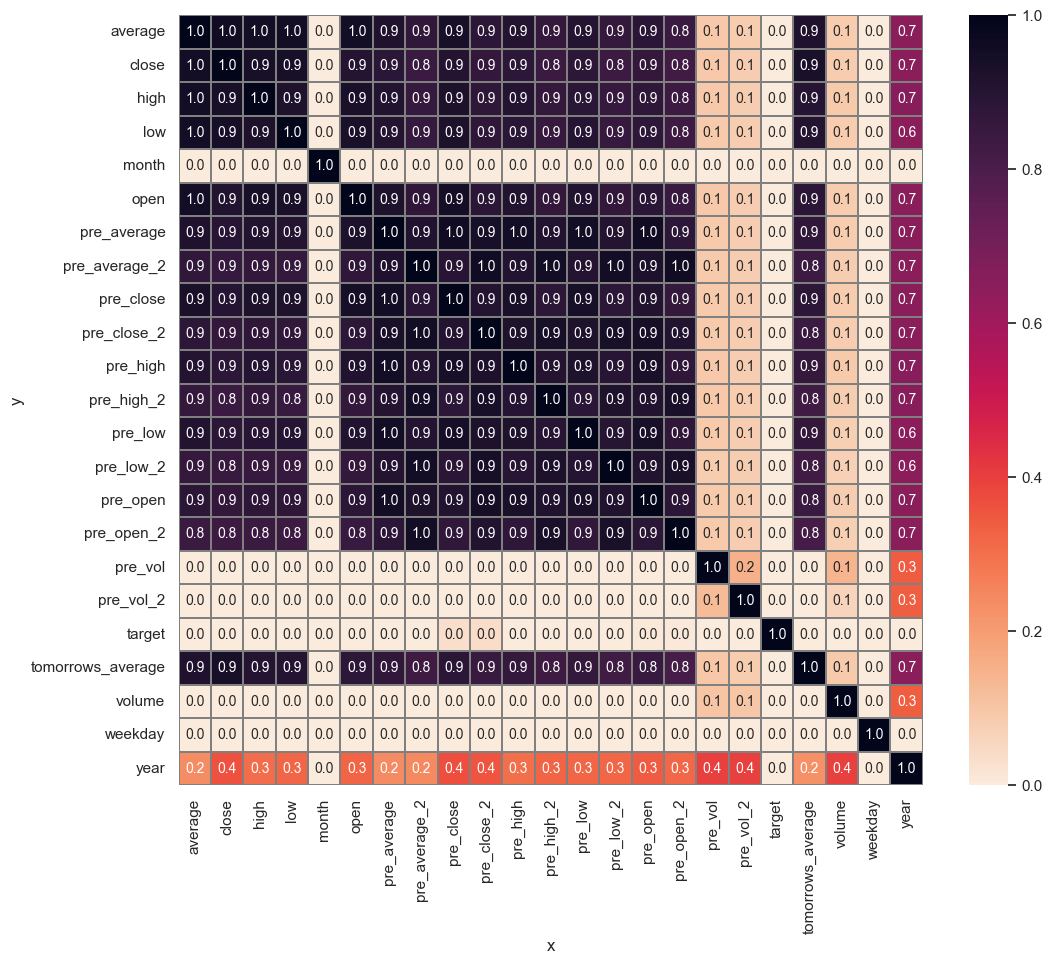

In [47]:
DisplayCorrAndPPS(df_corr_pearson = df_corr_pearson,
                  df_corr_spearman = df_corr_spearman, 
                  pps_matrix = pps_matrix,
                  CorrThreshold = 0.0, PPS_Threshold =0.0,
                  figsize=(12,10), font_annot=10)

Although we are achieving some high correlations between certain values (which can be expected with stock chart data) there is no significant correlation with the target variable, date-related features, or trading volume. Additionally, the Predictive Power Score (PPS) between the year and some features is moderate, generally ranging between 0.6 and 0.7. This indicates that year-based relationships have some predictive value, but time-based patterns alone may not be strong enough signals across the dataset

## Correlation-Based Feature Importance

Next, we use both Spearman and Pearson correlation methods to assess the strength of the relationship between each feature and the target variable. By taking the absolute values of the correlations, we can identify and rank features that may be most relevant to the target, regardless of the direction of the relationship

* Spearman (monotonic)

In [48]:
target_var = 'target'

corr_spearman = df.corr(method='spearman')[target_var].sort_values(key=abs, ascending=False)[1:]
corr_spearman

tomorrows_average    0.060285
weekday              0.044264
close                0.023156
volume               0.022228
year                 0.019205
open                -0.015280
pre_high_2          -0.010175
pre_high            -0.009726
pre_close           -0.009120
pre_average         -0.008657
pre_close_2         -0.008638
pre_low             -0.008056
pre_open            -0.008046
pre_average_2       -0.008005
pre_vol              0.007727
pre_low_2           -0.007467
pre_open_2          -0.007340
high                 0.005862
pre_vol_2            0.005051
low                  0.004908
month                0.004679
average              0.003709
Name: target, dtype: float64

* Pearson (linear)

In [49]:
corr_pearson = df.corr(method='pearson')[target_var].sort_values(key=abs, ascending=False)[1:]
corr_pearson

tomorrows_average    0.056784
weekday              0.039572
close                0.024837
year                 0.019217
high                 0.009480
open                -0.009167
low                  0.008895
average              0.007831
pre_vol              0.006476
pre_high            -0.004476
month                0.004463
pre_high_2          -0.004219
pre_close           -0.003750
pre_average         -0.003503
pre_close_2         -0.003416
pre_open            -0.003251
pre_low             -0.003164
pre_vol_2            0.002648
pre_average_2       -0.002615
pre_low_2           -0.002201
pre_open_2          -0.001810
volume              -0.001033
Name: target, dtype: float64

Both Spearman and Pearson correlation analyses indicate low levels of correlation between the features and the target variable

---

# EDA on Selected Variables

In [50]:
top_n = 5
top_vars  = set(corr_pearson[:top_n].index.to_list() + corr_spearman[:top_n].index.to_list())
top_vars

{'close', 'high', 'tomorrows_average', 'volume', 'weekday', 'year'}

In [51]:
vars_to_study = list(top_vars)
vars_to_study

['high', 'year', 'weekday', 'close', 'tomorrows_average', 'volume']

In [52]:
df_eda = df.filter(vars_to_study + [target_var])
df_eda.head(3)

,high,year,weekday,close,tomorrows_average,volume,target
2,497.583069,2010,2,497.583069,505.093023,10729.0,1
3,507.053752,2010,3,503.132294,503.132294,6169.0,0
4,503.132294,2010,4,503.132294,503.132294,6169.0,0


## Variables Distribution by Target

We plot the distribution (numerical and categorical) coloured by Traget

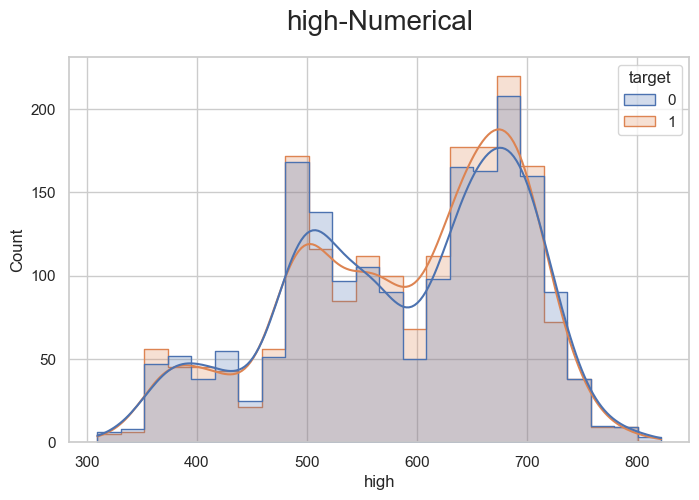

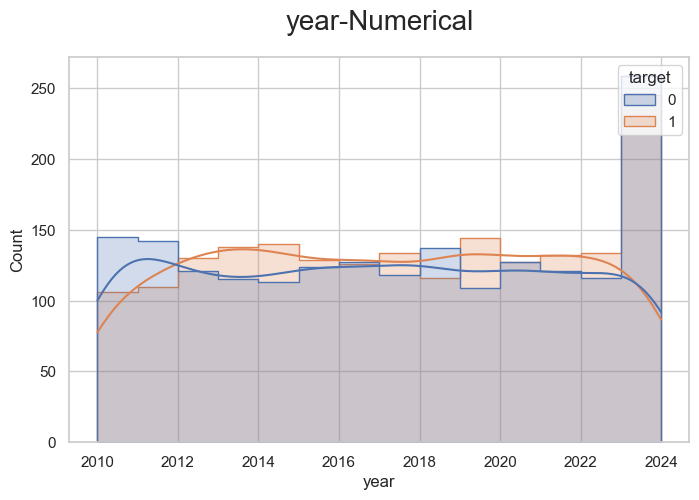

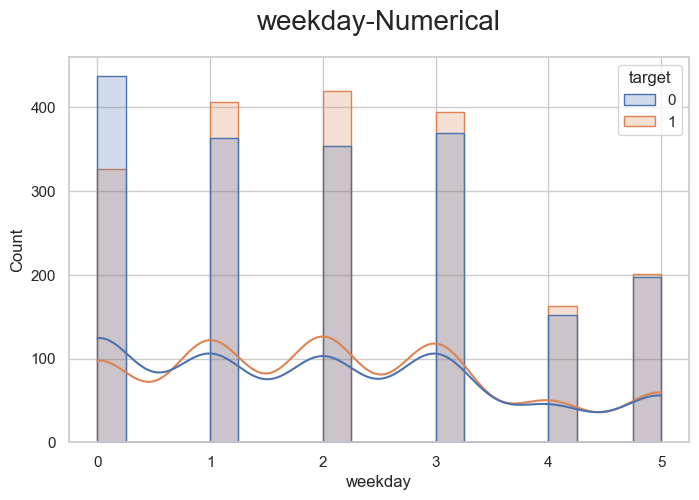

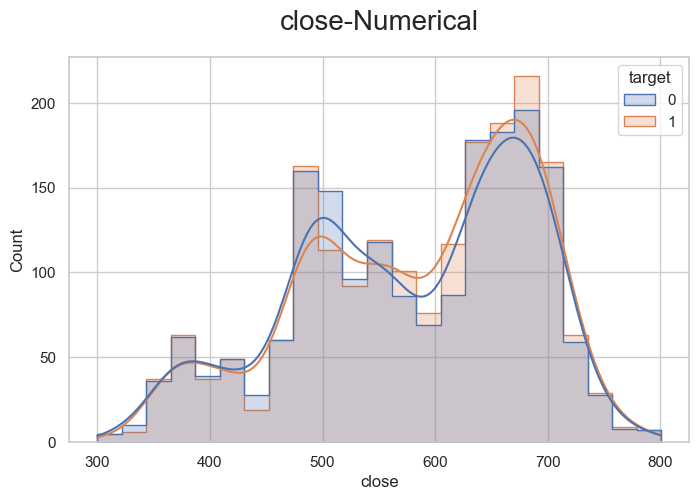

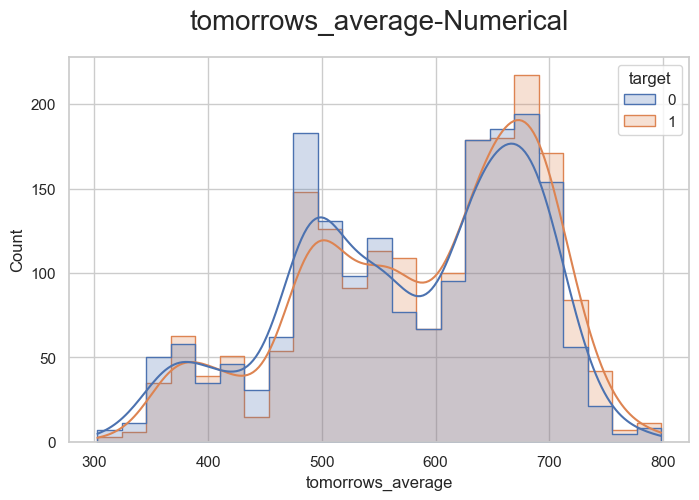

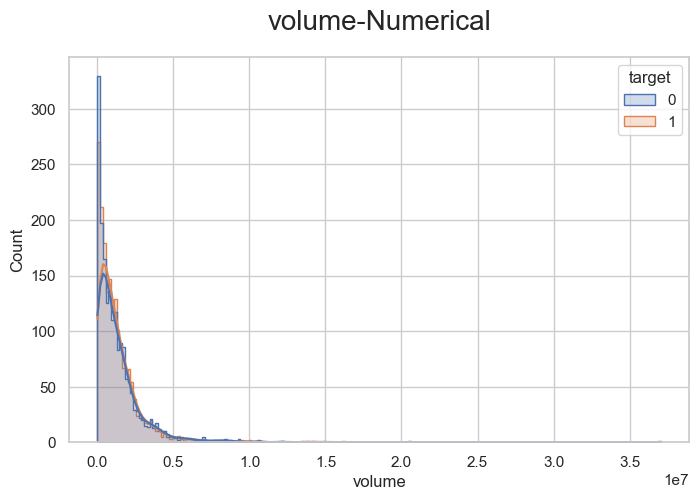

In [53]:
def plot_categorical(df, col, target_var):
    """
    Plot the distribution of a categorical feature with respect to a target variable

    Parameters:
        df (DataFrame): The dataset containing the data
        col (str): The name of the categorical column to plot
        target_var (str): The target variable for grouping (hue)
    """
    plt.figure(figsize=(12, 5))
    sns.countplot(data=df, x=col, hue=target_var, order=df[col].value_counts().index)
    plt.xticks(rotation=90)
    plt.title(f"{col}-Categorical", fontsize=20, y=1.05)
    plt.show()


def plot_numerical(df, col, target_var):
    """
    Plot the distribution of a numerical feature grouped by a target variable

    Parameters:
        df (DataFrame): The dataset containing the data
        col (str): The name of the numerical column to plot
        target_var (str): The target variable for grouping (hue)
    """
    plt.figure(figsize=(8, 5))
    sns.histplot(data=df, x=col, hue=target_var, kde=True, element="step")
    plt.title(f"{col}-Numerical", fontsize=20, y=1.05)
    plt.show()


for col in vars_to_study:
    if df_eda[col].dtype == 'object':
        plot_categorical(df_eda, col, target_var)
        print("\n\n")
    else:
        plot_numerical(df_eda, col, target_var)
        print("\n\n")

We have observed that, among the selected variables, the target variable is very well balanced, indicating that there are no features with strong enough directional influence to predict market movements

---

# Parallel Plot

Create a separate DataFrame and transform tomorrowa average (numerical) into bins (categorical) for visualising at parallel_categories() plot

In [54]:
median = df['tomorrows_average'].median()
print(median)

603.3061457949641


In [55]:
bin_map = [-np.inf, 500, 600, 700, np.inf]
disc = ArbitraryDiscretiser(binning_dict={'tomorrows_average': bin_map})
df_parallel = disc.fit_transform(df_eda)
df_parallel.head()

,high,year,weekday,close,tomorrows_average,volume,target
2,497.583069,2010,2,497.583069,1,10729.0,1
3,507.053752,2010,3,503.132294,1,6169.0,0
4,503.132294,2010,4,503.132294,1,6169.0,0
5,503.132294,2010,0,503.132294,0,6169.0,0
6,499.432739,2010,1,499.432739,0,6169.0,1


In [56]:
disc.binner_dict_['tomorrows_average']

[-inf, 500, 600, 700, inf]

In [57]:
n_classes = len(bin_map) - 1
classes_ranges = disc.binner_dict_['tomorrows_average'][1:-1]

labels_map = {}
for n in range(0, n_classes):
    if n == 0:
        labels_map[n] = f"<{classes_ranges[0]}"  
    elif n == n_classes - 1:
        labels_map[n] = f"+{classes_ranges[-1]}" 
    else:
        labels_map[n] = f"{classes_ranges[n-1]} to {classes_ranges[n]}" 

labels_map

{0: '<500', 1: '500 to 600', 2: '600 to 700', 3: '+700'}

In [58]:
df_parallel['tomorrows_average'] = df_parallel['tomorrows_average'].replace(labels_map)
df_parallel

,high,year,weekday,close,tomorrows_average,volume,target
2,497.583069,2010,2,497.583069,500 to 600,10729.0,1
3,507.053752,2010,3,503.132294,500 to 600,6169.0,0
4,503.132294,2010,4,503.132294,500 to 600,6169.0,0
5,503.132294,2010,0,503.132294,<500,6169.0,0
6,499.432739,2010,1,499.432739,<500,6169.0,1
...,...,...,...,...,...,...,...
3782,502.260368,2024,4,500.261322,<500,3415182.0,0
3783,502.260357,2024,0,501.260834,500 to 600,1071229.0,1
3784,505.258920,2024,1,501.760590,500 to 600,436491.0,0
3785,503.759655,2024,4,502.760132,500 to 600,881757.0,0


In [59]:
fig = px.parallel_categories(df_parallel, color='target')
fig.show(renderer='jupyterlab')

The parallel plot shows how balanced the target classes are across different years and days of the week

---

# Reviewing Outliners

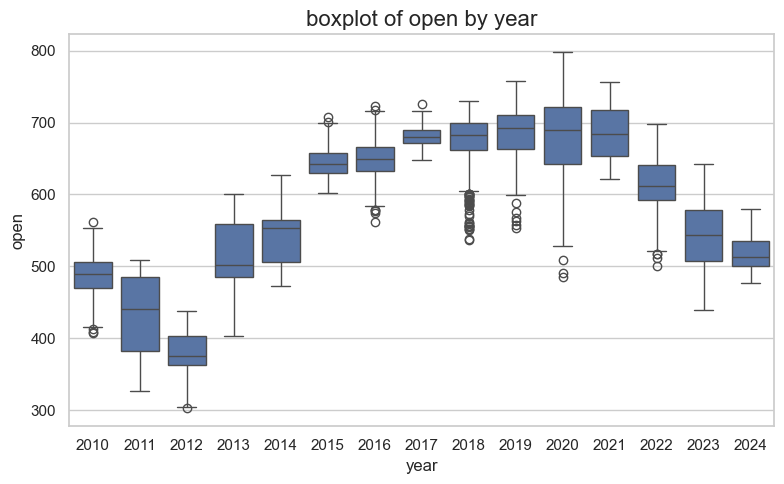

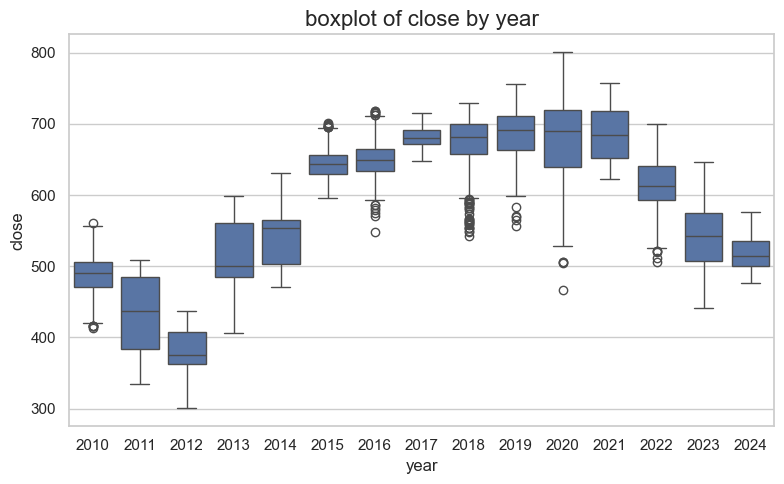

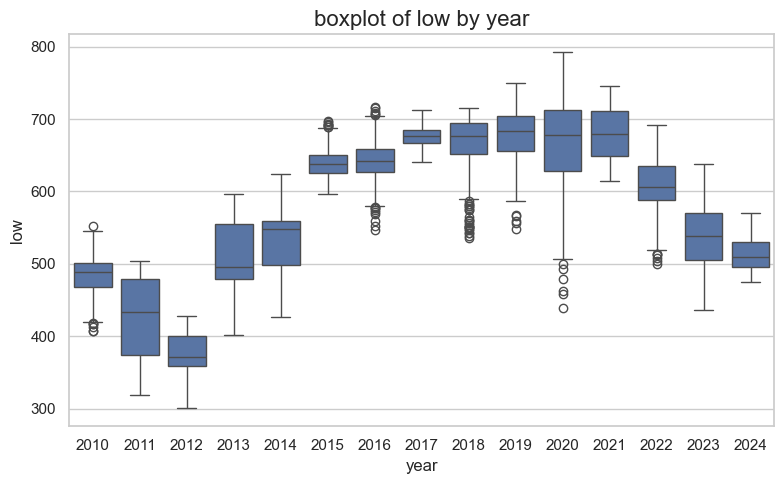

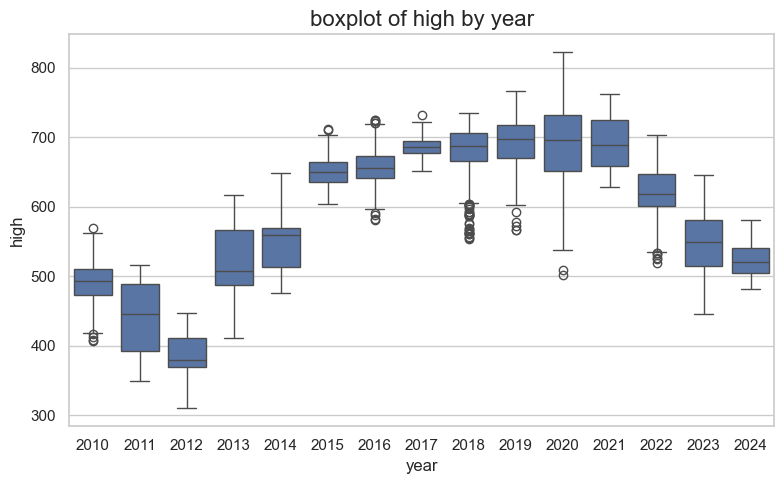

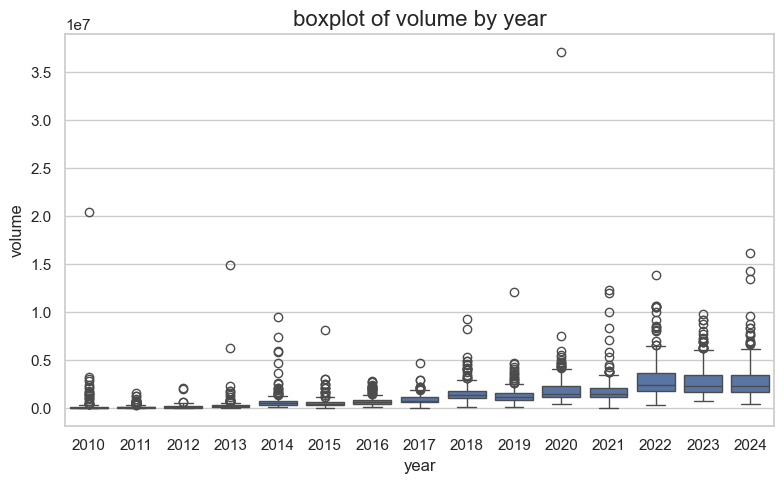

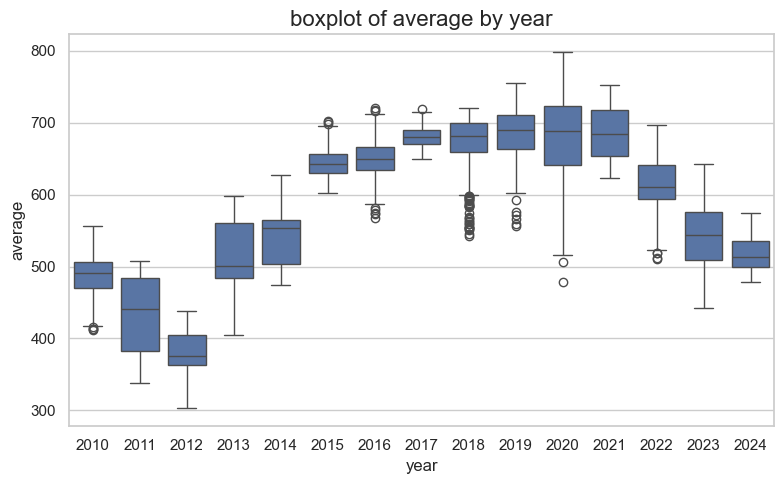

In [60]:
columns = ['open', 'close', 'low', 'high', 'volume', 'average']

for col in columns:
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=df, x='year', y=col) 
    plt.title(f"boxplot of {col} by year", fontsize=16)
    plt.tight_layout()
    plt.show()

In analyzing the stock data, several outliers were observed across the different features. However, these outliers are not spread widely and tend to be closely clustered together. This indicates that while there are extreme values, they do not diverge significantly from the overall trend, suggesting that they might represent specific periods of unusual but not entirely anomalous market behavior. The closeness of these outliers may imply that they are part of short-term fluctuations within the stock's price movement, rather than true anomalies. This characteristic could be important for further analysis as it might help distinguish between regular market volatility and rare, exceptional events

---

# Stock Risk Assessment: Analyzing Highs, Lows, and Volume Trends

In [61]:
yearly_stats = df.groupby('year').agg({
    'high': 'max',
    'low': 'min',
    'volume': 'sum',
})

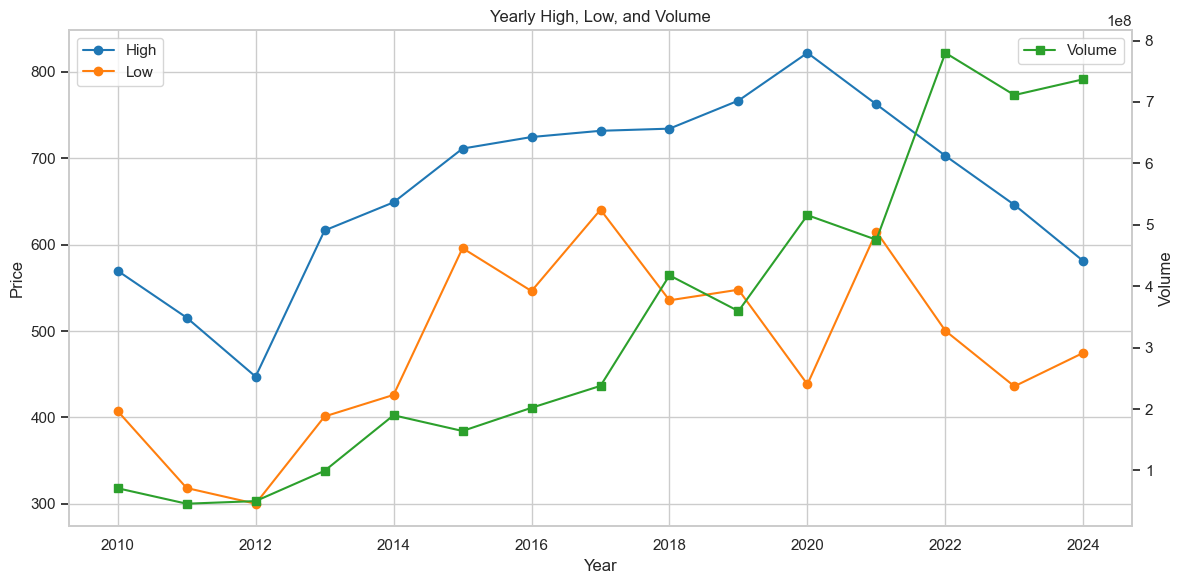

In [62]:
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(yearly_stats.index, yearly_stats['high'], marker='o', label='High', color='tab:blue')
ax1.plot(yearly_stats.index, yearly_stats['low'], marker='o', label='Low', color='tab:orange')
ax1.set_xlabel('Year')
ax1.set_ylabel('Price')
ax1.legend(loc='upper left')
ax1.grid(True)

ax2 = ax1.twinx()
ax2.plot(yearly_stats.index, yearly_stats['volume'], marker='s', label='Volume', color='tab:green')
ax2.set_ylabel('Volume')
ax2.legend(loc='upper right')

plt.title("Yearly High, Low, and Volume")
plt.tight_layout()
plt.grid(axis='y')
plt.show()

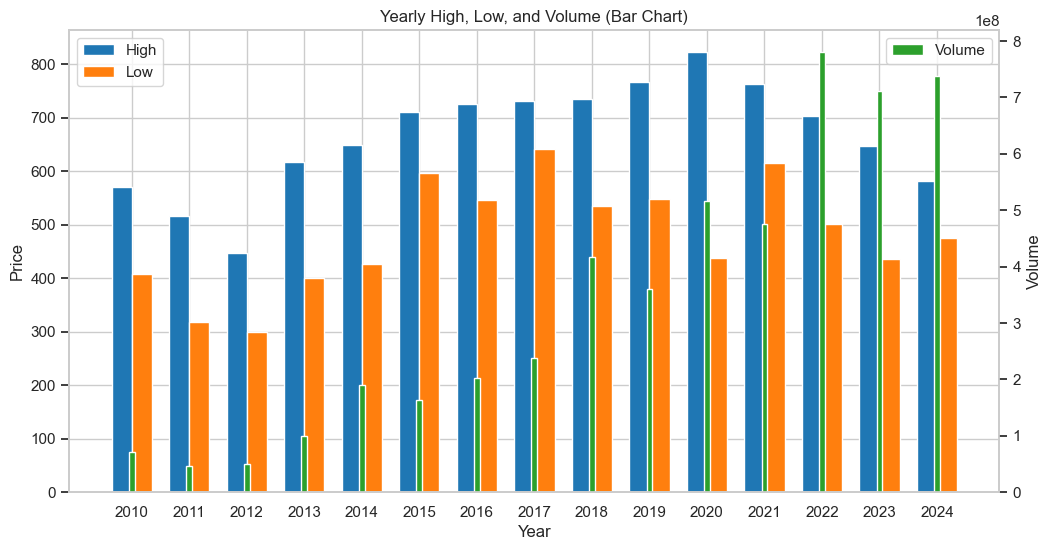

In [63]:
years = yearly_stats.index
bar_width = 0.35
x = range(len(years))

fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.bar([p - bar_width/2 for p in x], yearly_stats['high'], bar_width, label='High', color='tab:blue')
ax1.bar([p + bar_width/2 for p in x], yearly_stats['low'], bar_width, label='Low', color='tab:orange')
ax1.set_ylabel('Price')
ax1.set_xlabel('Year')
ax1.set_xticks(x)
ax1.set_xticklabels(years)
ax1.legend(loc='upper left')

ax2 = ax1.twinx()
ax2.bar(x, yearly_stats['volume'], width=0.1, label='Volume', color='tab:green')
ax2.set_ylabel('Volume')
ax2.legend(loc='upper right')

plt.title('Yearly High, Low, and Volume (Bar Chart)')
plt.grid(axis='y')
plt.show()

These charts compare yearly high and low stock prices with total trading volume. Over the past 15 years, stock prices have remained within a relatively close range, while trading volume has experienced a strong upward trend. Notably, between 2015 and 2020, there was an upward movement in stock prices, indicating a possible bullish trend during that period. However, following this upward movement, prices declined, returning close to their 2010 levels. This suggests that the stock may not have offered significant long-term gains for holders who did not sell during the bullish phase. Nonetheless, the current lower price levels could represent a potential entry point for new investors, especially if underlying fundamentals remain strong

---

# Save Correlation and PPS Heatmaps

In [64]:
dir = 'docs/plots'

try:
    os.makedirs(name=dir)
    print(f"directory {dir} created")

except Exception as e:
    print(e)

directory docs/plots created


spearman heatmap saved


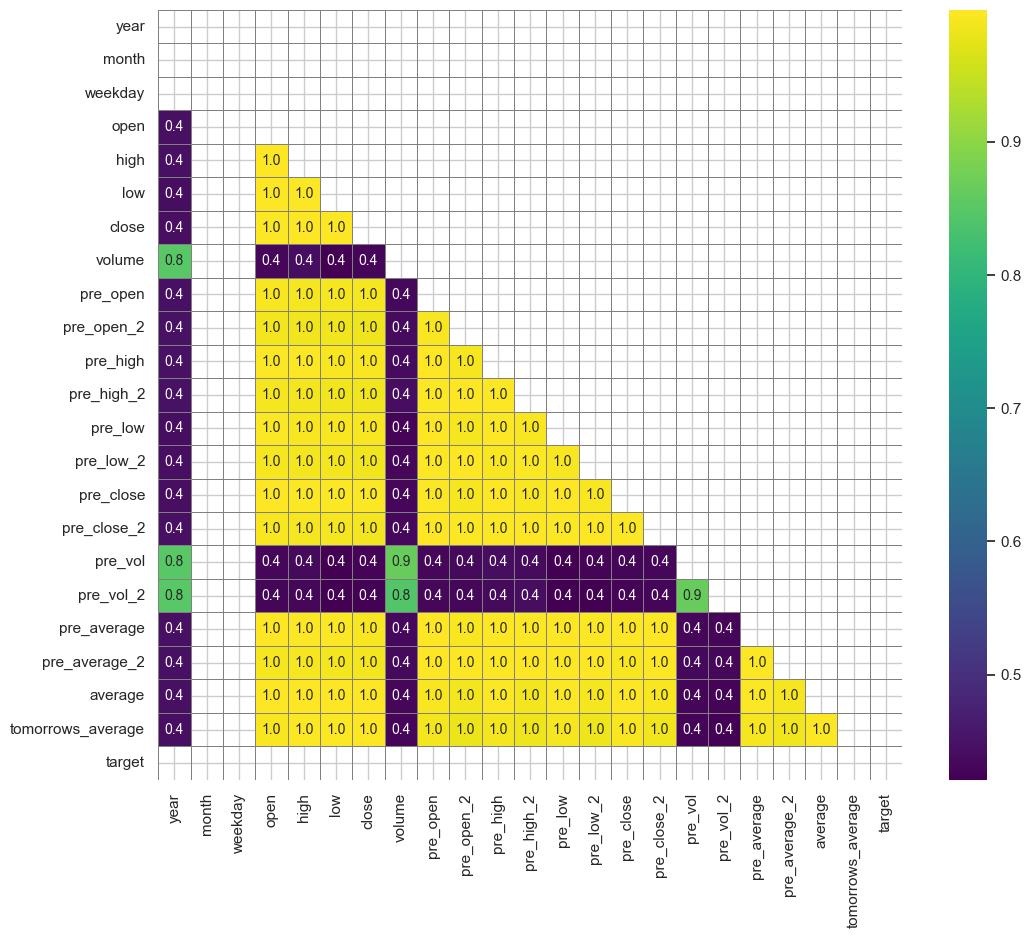

In [65]:
mask = np.zeros_like(df_corr_spearman, dtype=bool)
mask[np.triu_indices_from(mask)] = True
mask[abs(df_corr_spearman) < 0.4] = True

fig, axes = plt.subplots(figsize=(12,10))
sns.heatmap(df_corr_spearman, annot=True, xticklabels=True, yticklabels=True,
                mask=mask, cmap='viridis', annot_kws={"size": 10},
                fmt='.1f', ax=axes,
                linewidth=0.5, linecolor='grey')
axes.set_yticklabels(df_corr_spearman.columns, rotation=0)
plt.ylim(len(df_corr_spearman.columns), 0)
plt.savefig(f'{dir}/spearman_corr.png', format='png', dpi=300, bbox_inches='tight')
print('spearman heatmap saved')
plt.show()

pearson heatmap saved


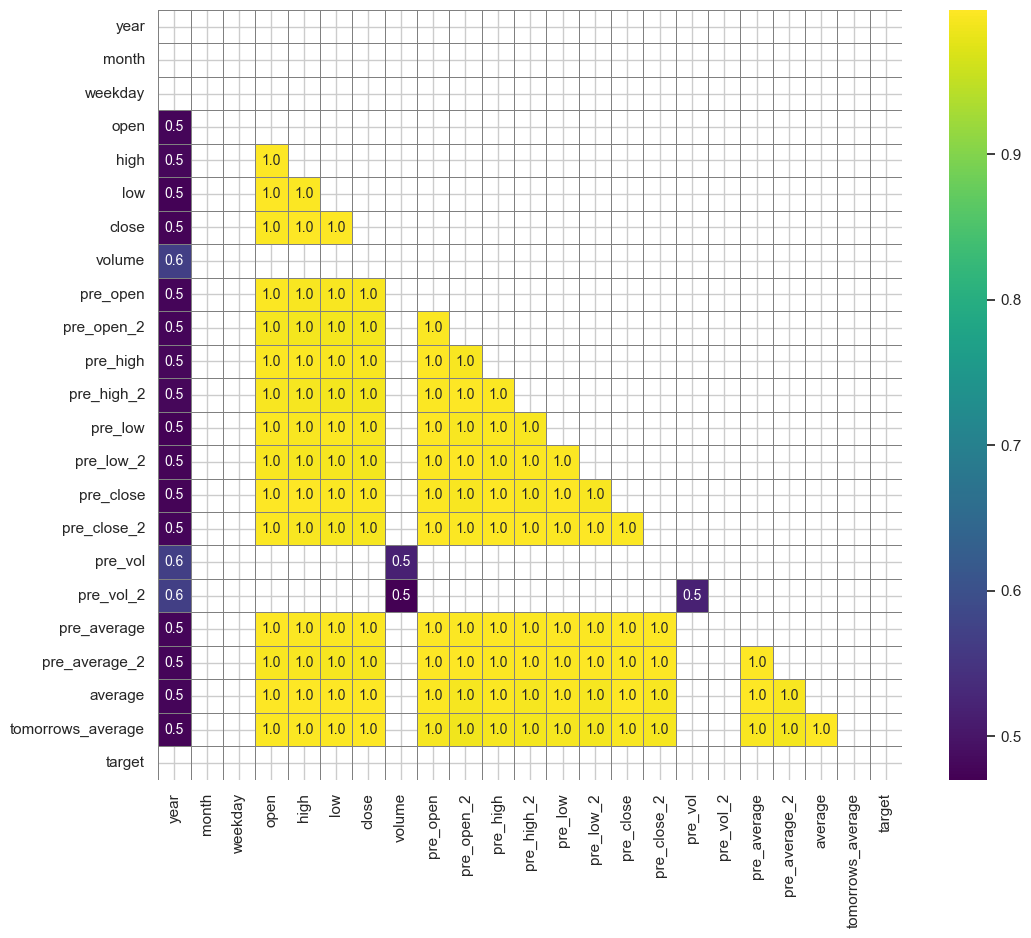

In [66]:
mask = np.zeros_like(df_corr_pearson, dtype=bool)
mask[np.triu_indices_from(mask)] = True
mask[abs(df_corr_pearson) < 0.4] = True

fig, axes = plt.subplots(figsize=(12,10))
sns.heatmap(df_corr_pearson, annot=True, xticklabels=True, yticklabels=True,
                mask=mask, cmap='viridis', annot_kws={"size": 10},
                fmt='.1f', ax=axes,
                linewidth=0.5, linecolor='grey')
axes.set_yticklabels(df_corr_pearson.columns, rotation=0)
plt.ylim(len(df_corr_pearson.columns), 0)
plt.savefig(f'{dir}/pearson_corr.png', format='png', dpi=300, bbox_inches='tight')
print('pearson heatmap saved')
plt.show()

pps heatmap saved


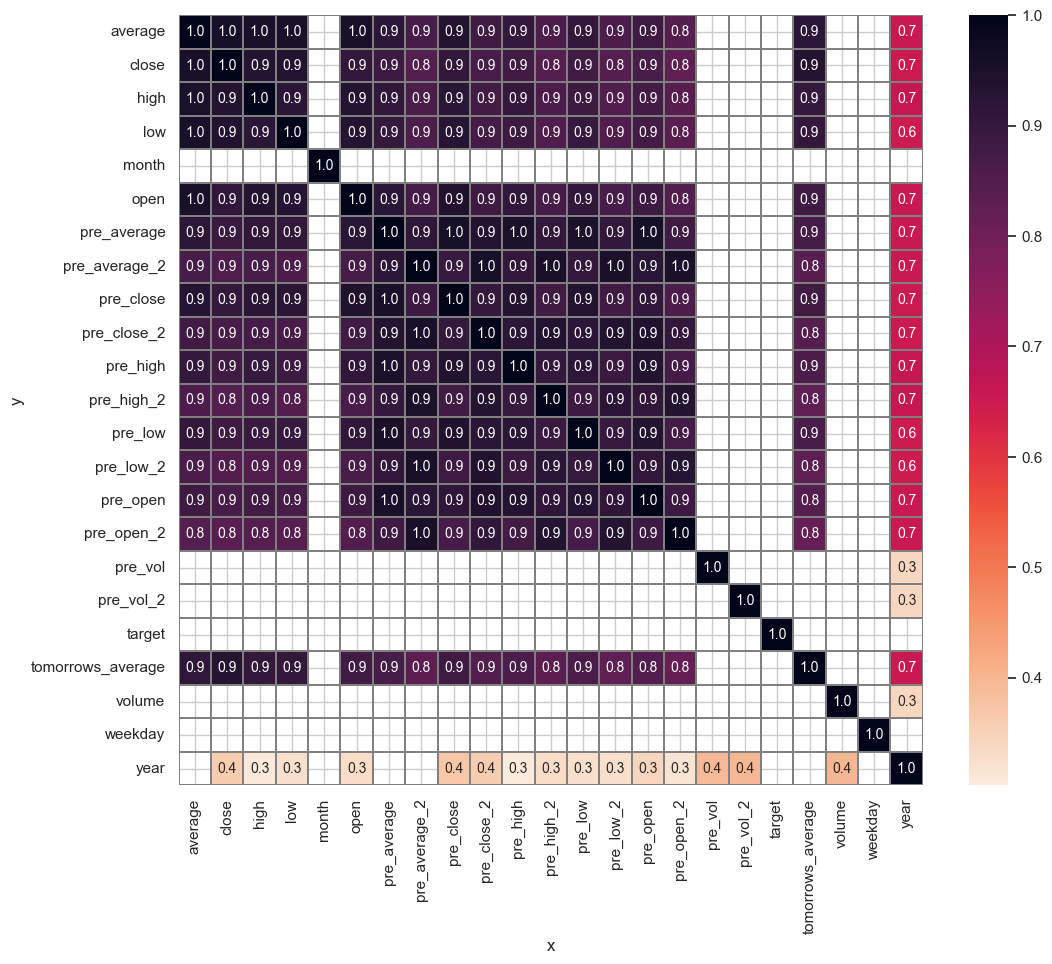

In [67]:
mask = np.zeros_like(pps_matrix, dtype=bool)
mask[abs(pps_matrix) < 0.3] = True

fig, ax = plt.subplots(figsize=(12,10))
ax = sns.heatmap(pps_matrix, annot=True, xticklabels=True, yticklabels=True,
                    mask=mask, cmap='rocket_r', annot_kws={"size": 10},
                    fmt='.1f',
                    linewidth=0.05, linecolor='grey')
plt.ylim(len(pps_matrix.columns), 0)
plt.savefig(f'{dir}/pps_matrix.png', format='png', dpi=300, bbox_inches='tight')
print('pps heatmap saved')
plt.show()

## Save Chart Plots

line plot saved


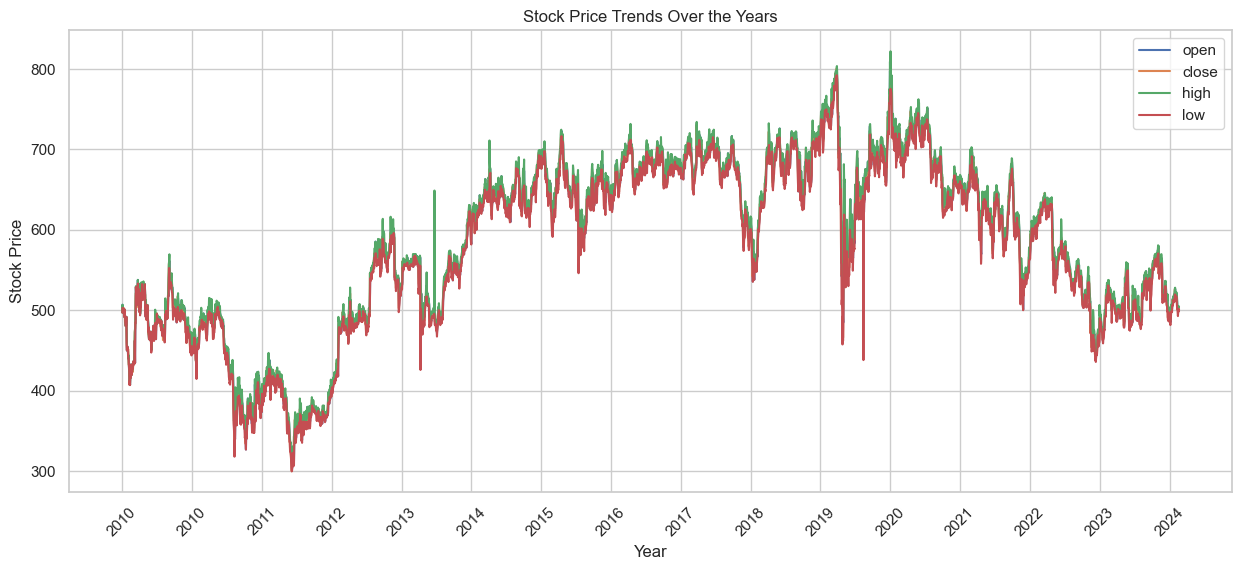

In [68]:
df.plot.line(y=['open', 'close', 'high', 'low'], figsize=(15, 6))

plt.xticks(ticks=df.index[::250], labels=df['year'][::250], rotation=45)
plt.title('Stock Price Trends Over the Years')
plt.xlabel('Year')
plt.ylabel('Stock Price')
plt.savefig(f'{dir}/line_plot.png', format='png', dpi=300, bbox_inches='tight')
print('line plot saved')
plt.show()

volume plot saved


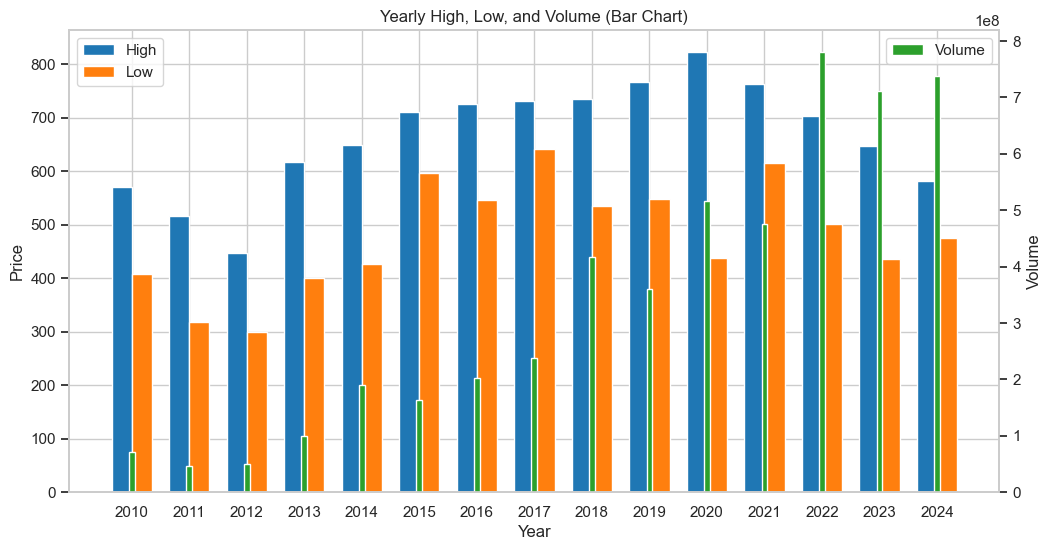

In [69]:
years = yearly_stats.index
bar_width = 0.35
x = range(len(years))

fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.bar([p - bar_width/2 for p in x], yearly_stats['high'], bar_width, label='High', color='tab:blue')
ax1.bar([p + bar_width/2 for p in x], yearly_stats['low'], bar_width, label='Low', color='tab:orange')
ax1.set_ylabel('Price')
ax1.set_xlabel('Year')
ax1.set_xticks(x)
ax1.set_xticklabels(years)
ax1.legend(loc='upper left')

ax2 = ax1.twinx()
ax2.bar(x, yearly_stats['volume'], width=0.1, label='Volume', color='tab:green')
ax2.set_ylabel('Volume')
ax2.legend(loc='upper right')

plt.title('Yearly High, Low, and Volume (Bar Chart)')
plt.grid(axis='y')
plt.savefig(f'{dir}/volume_plot.png', format='png', dpi=300, bbox_inches='tight')
print('volume plot saved')
plt.show()

---

# Conclusions and Next Steps

* Exploratory Data Analysis (EDA): We performed an exploratory analysis, adding relevant features and targets for both regression and classification tasks in supervised learning

* Data Quality: The dataset was clean with no missing values. A small amount of missing data was introduced when shifting columns to create new features, but the volume was minimal and dropping them did not affect the analysis

* Feature Correlation: There is a high correlation between stock-related numerical features (open, close, low, high), which is typical for stock data. However, there is very little correlation between the targets, time/date features, and volume, indicating potential unpredictability in the stock trends

* Observed Trend: A relatively stable trend was observed in high and low values over the years, while trading volume demonstrated a noticeable increase

* Next Steps: The next step will be to re-add the features, clean the data further, and then split it into training and testing sets. This will prepare the data for the feature engineering stage